### 2 -Crie uma fun ̧c ̃ao aproximacao posto r(imagem, r) que:
(a) Calcule a decomposiçao SVD da imagem.

(b) Construa a aproxima ̧c ̃ao de posto r usando apenas os primeiros r valores singulares.

(c) Calcule o erro de Frobenius de duas formas:

• M ́etodo direto: ∥A − Ar∥F (norma da diferen ̧ca das matrizes).
• M ́etodo te ́orico: p

(d) Verifique se os dois m ́etodos produzem o mesmo resultado.
(e) Retorne a imagem aproximada e o erro calculado.
Teste com diferentes valores de r: 1, 5, 10, 20, 50, 100 e compare os erros.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

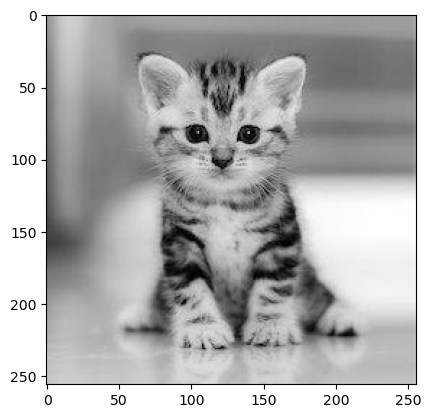

In [2]:
img = plt.imread('kitten.jpg')

plt.imshow(img, cmap='gray')

In [ ]:
def aproximacao_posto_r(imagem, r):
    U, S, Vt = np.linalg.svd(imagem) # item a

    # Reconstrucao 
    if r > S.shape[0]:
        r = S.shape[0]

    rec_img = U[:, :r] @ np.diag(S[:r]) @ Vt[:r] # item b

    err_convencional = np.linalg.norm(imagem -  rec_img) # item c
    err_teorico =  np.sqrt((S[r:] ** 2).sum()) # item c

    if np.allclose(err_convencional, err_teorico): # item d
        print('Os erros batem')
    else:
        print('Os erros são diferentes')
    return rec_img,err_convencional, err_teorico # item e

In [5]:
for r in [1, 5, 10, 20, 50, 100]:
    _, err_c, err_t = aproximacao_posto_r(img, r)
    print(err_c)

Os erros batem
10911.646247261686
Os erros batem
5260.941324480974
Os erros batem
3675.270032190636
Os erros batem
2258.851775157449
Os erros batem
1060.276858773027
Os erros batem
279.2023775181084


4. Implemente uma fun ̧c ̃ao analisar compressao(imagem) que:

1

(a) Calcule aproxima ̧c ̃oes para r variando de 1 at ́e o posto m ́aximo da imagem.

(b) Para cada r, calcule:
• Taxa de compress ̃ao: razao compressao =
r(m+n+1)
mn
.

• Erro relativo: erro relativo = ∥A−Ar∥F
∥A∥F
.

• PSNR (Peak Signal-to-Noise Ratio): PSNR = 20 log10
255
RMSE 
.

(c) Plote trˆes gr ́aficos:
• Erro relativo vs. r.
• Taxa de compress ̃ao vs. r.
• PSNR vs. Taxa de compress ̃ao.
(d) Identifique o ”ponto  ́otimo” onde se obt ́em boa qualidade com alta compress ̃ao.
F ́ormula do RMSE: p

mean((A − Ar)
2
).

In [26]:
def  analisar_compressao(imagem):
    U, S, Vt = np.linalg.svd(imagem,full_matrices=False)

    taxa_compress = []
    erro_relativo = []
    PSNR = []

    n, m = imagem.shape

    mn = m*n
    mn1 = m + n + 1

    norm_img = np.linalg.norm(imagem)
    for r in range(1, S.shape[0] + 1):
        rec = U[:,:r] @ np.diag(S[:r]) @ Vt[:r]

        taxa_compress.append((r * mn1)/mn)

        err = np.sqrt((S[r:] ** 2).sum()) # formula teorica
        
        erro_relativo.append(err/norm_img)

        rmse = np.sqrt(((imagem - rec)**2).mean())
        PSNR.append(20 * np.log10(255./ rmse))

    fig, ax = plt.subplots(2, 2, figsize=(10,10))

    r = np.arange(S.shape[0]) + 1
    ax[0,0].plot(r, erro_relativo)
    ax[0,0].set_title('Erro relativo')
    ax[0,0].set_xlabel('r')
    ax[0,0].set_ylabel('Erro relativo')
    ax[0,0].set_yscale('log')
    
    ax[0,1].plot(r, taxa_compress)
    ax[0,1].set_title('Taxa de compressão')
    ax[0,1].set_xlabel('r')
    ax[0,1].set_ylabel('Taxa de compressão')

    ax[1,0].plot(r, PSNR)
    ax[1,0].set_title('PSNR')
    ax[1,0].set_xlabel('r')
    ax[1,0].set_ylabel('PSNR')
    ax[1,0].set_yscale('log')

    ax[1,1].plot(taxa_compress, PSNR)
    ax[1,1].set_title('Compressão x PSNR')
    ax[1,1].set_xlabel('Taxa de compressão')
    ax[1,1].set_ylabel('PSNR')
    ax[1,1].set_yscale('log')



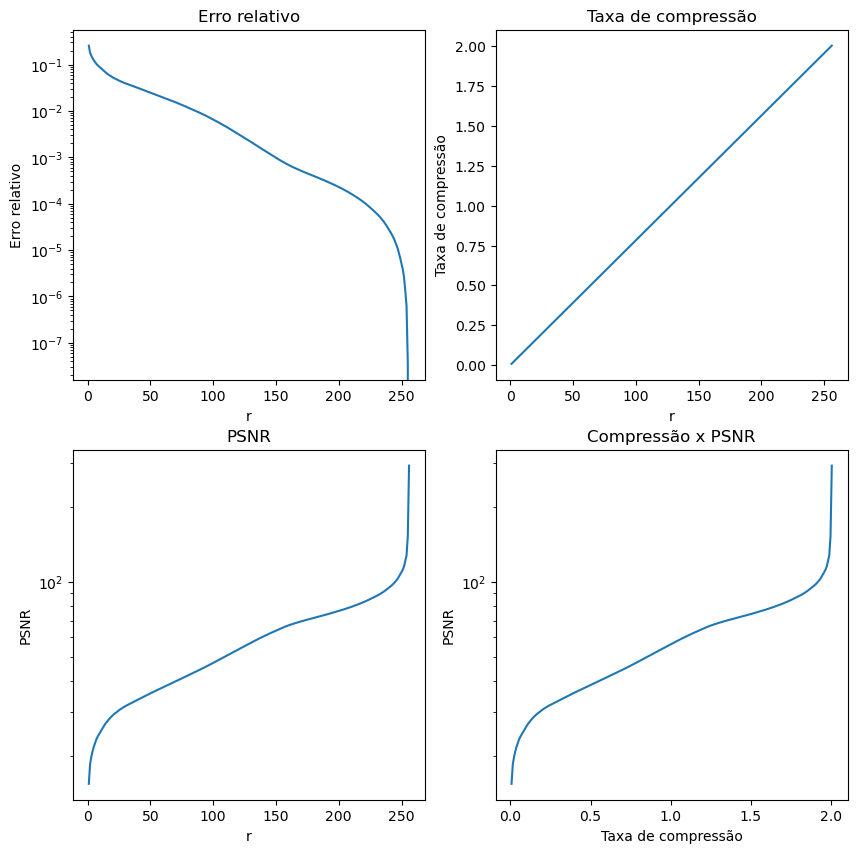

In [27]:
analisar_compressao(img)